2.501074975068696e-30
1.5814787305141654e-15
1.0


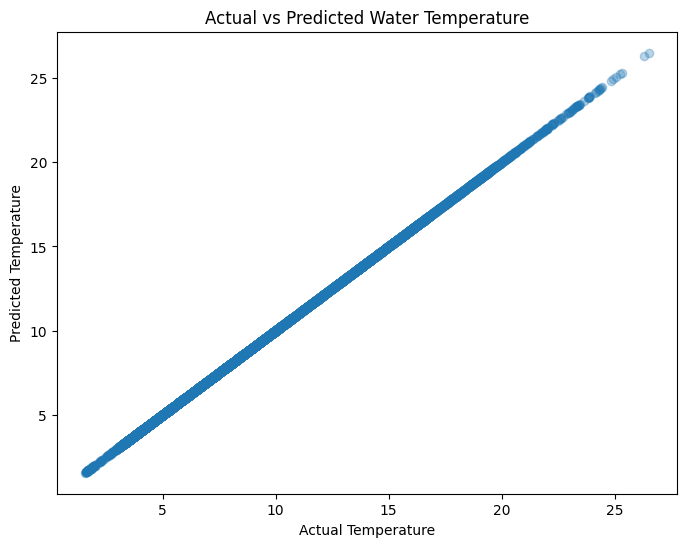

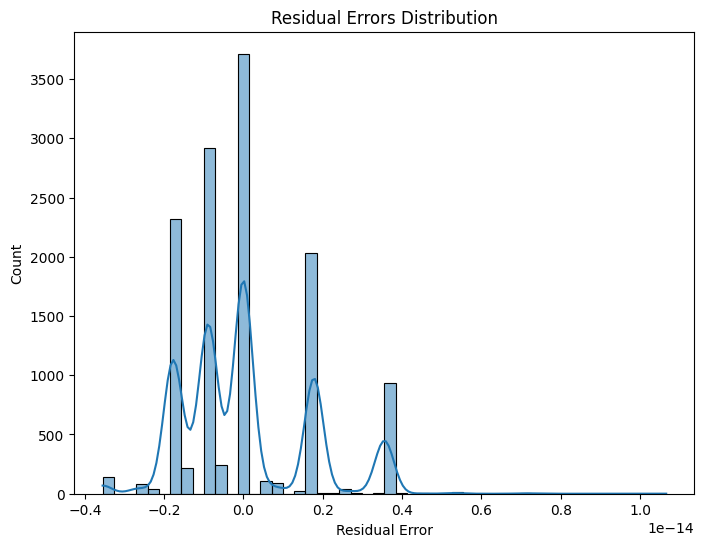

1.9299930384710696e-08
9.92345411692727e-05


In [3]:
S.ASWIN 24BADO14

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("bottle.csv", low_memory=False)

features = ["Depthm", "Salnty", "O2ml_L", "R_TEMP", "R_SALINITY"]
target = "T_degC"

data = df[features + [target]]

imputer = SimpleImputer(strategy="median")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

X = data_imputed[features]
y = data_imputed[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse)
print(rmse)
print(r2)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Water Temperature")
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Errors Distribution")
plt.xlabel("Residual Error")
plt.show()

features_reduced = ["Depthm", "Salnty", "R_TEMP"]

X2 = data_imputed[features_reduced]
X2_scaled = scaler.fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train2, y_train2)
y_pred_ridge = ridge.predict(X_test2)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train2, y_train2)
y_pred_lasso = lasso.predict(X_test2)

print(mean_squared_error(y_test2, y_pred_ridge))
print(mean_squared_error(y_test2, y_pred_lasso))


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

df = pd.read_csv("/content/LICI - Daily data.csv")

df["Price_Movement"] = (df["Close"] > df["Open"]).astype(int)

features = ["Open", "High", "Low", "Volume"]
target = "Price_Movement"

data = df[features + [target]]

imputer = SimpleImputer(strategy="median")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

X = data_imputed[features]
y = data_imputed[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

plt.figure()
plt.bar(features, np.abs(log_model.coef_[0]))
plt.title("Feature Importance")
plt.ylabel("Coefficient Magnitude")
plt.show()

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="f1",
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best C:", grid.best_params_["C"])
print("Tuned F1:", f1_score(y_test, y_pred_best))


KeyError: "['Volume'] not in index"

In [5]:
print(df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Price_Movement'], dtype='object')


Accuracy: 0.95
Precision: 1.0
Recall: 0.8333333333333334
F1-score: 0.9090909090909091
Confusion Matrix:
 [[14  0]
 [ 1  5]]


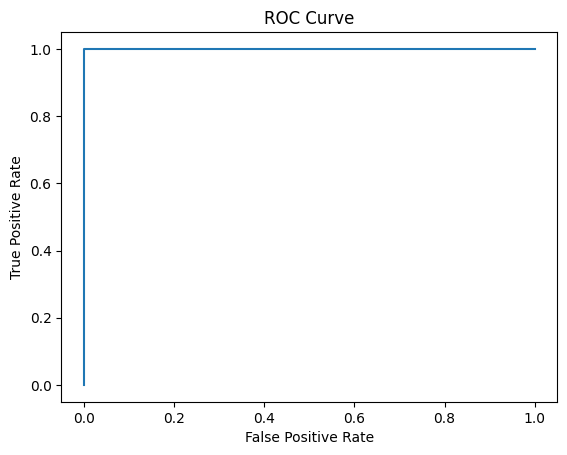

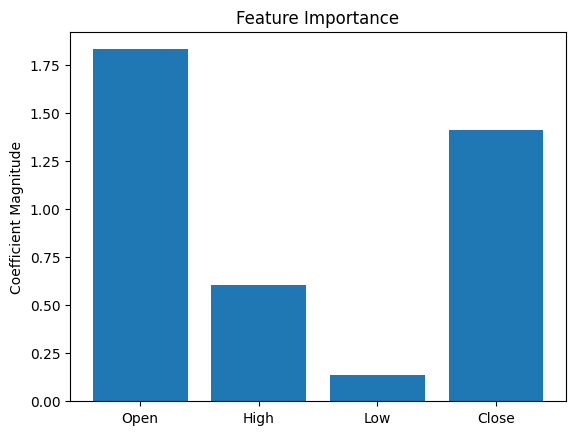

Best C: 10
Tuned F1: 1.0


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

df = pd.read_csv("/content/LICI - Daily data.csv")

df["Price_Movement"] = (df["Close"] > df["Open"]).astype(int)

features = ["Open", "High", "Low", "Close"]
target = "Price_Movement"

data = df[features + [target]]

imputer = SimpleImputer(strategy="median")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

X = data_imputed[features]
y = data_imputed[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

plt.figure()
plt.bar(features, np.abs(log_model.coef_[0]))
plt.title("Feature Importance")
plt.ylabel("Coefficient Magnitude")
plt.show()

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="f1",
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best C:", grid.best_params_["C"])
print("Tuned F1:", f1_score(y_test, y_pred_best, zero_division=0))
